# Linked-Read (NAIBR)
Here, we aggregate the visualizations of all size classes and depth treatments for linked-read simulations.

In [1]:
library(ggplot2)
library(ggpattern)
library(dplyr)
library(ggpubr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Let's read in the data from the outcomes of the individual size-class assessments and combine them into a single table. Since we'll be comparing this to the long-read data, we should also add a column specifing this is linked-read data and write the entire thing into one file.

In [2]:
lr_inversions <- rbind(
    read.csv("small.sv.naibr.assessment", header = T),
    read.csv("medium.sv.naibr.assessment", header = T),
    read.csv("large.sv.naibr.assessment", header = T),
    read.csv("xl.sv.naibr.assessment", header = T)
)
lr_inversions$technology <- "linkedread"
lr_inversions$method <- "naibr"
if(!file.exists("linkedread.sv.naibr.assessment")){
    write.csv(lr_inversions, file = "linkedread.sv.naibr.assessment", row.names = F, quote = F)
}
head(lr_inversions)

,contig,inversion,id,depth,sample,size,simulated,zygosity,assessment,position_start,position_end,technology,method
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
1,2L,1,1,0.5,11,small,TRUE,hom,false negative,3193196,3214221,linkedread,naibr
2,2L,1,1,0.5,7,small,TRUE,hom,false negative,3193196,3214221,linkedread,naibr
3,2L,1,1,0.5,5,small,TRUE,hom,false negative,3193196,3214221,linkedread,naibr
4,2L,1,1,0.5,1,small,TRUE,hom,false negative,3193196,3214221,linkedread,naibr
5,2L,1,1,0.5,10,small,TRUE,hom,false negative,3193196,3214221,linkedread,naibr
6,2L,1,1,0.5,3,small,TRUE,hom,false negative,3193196,3214221,linkedread,naibr


### Single-Sample Detection
Let's visualize what detection looked like across all treatments with respect to false/true positive/negative. Here, we facet rows across depths and show all the size treatments across columns.

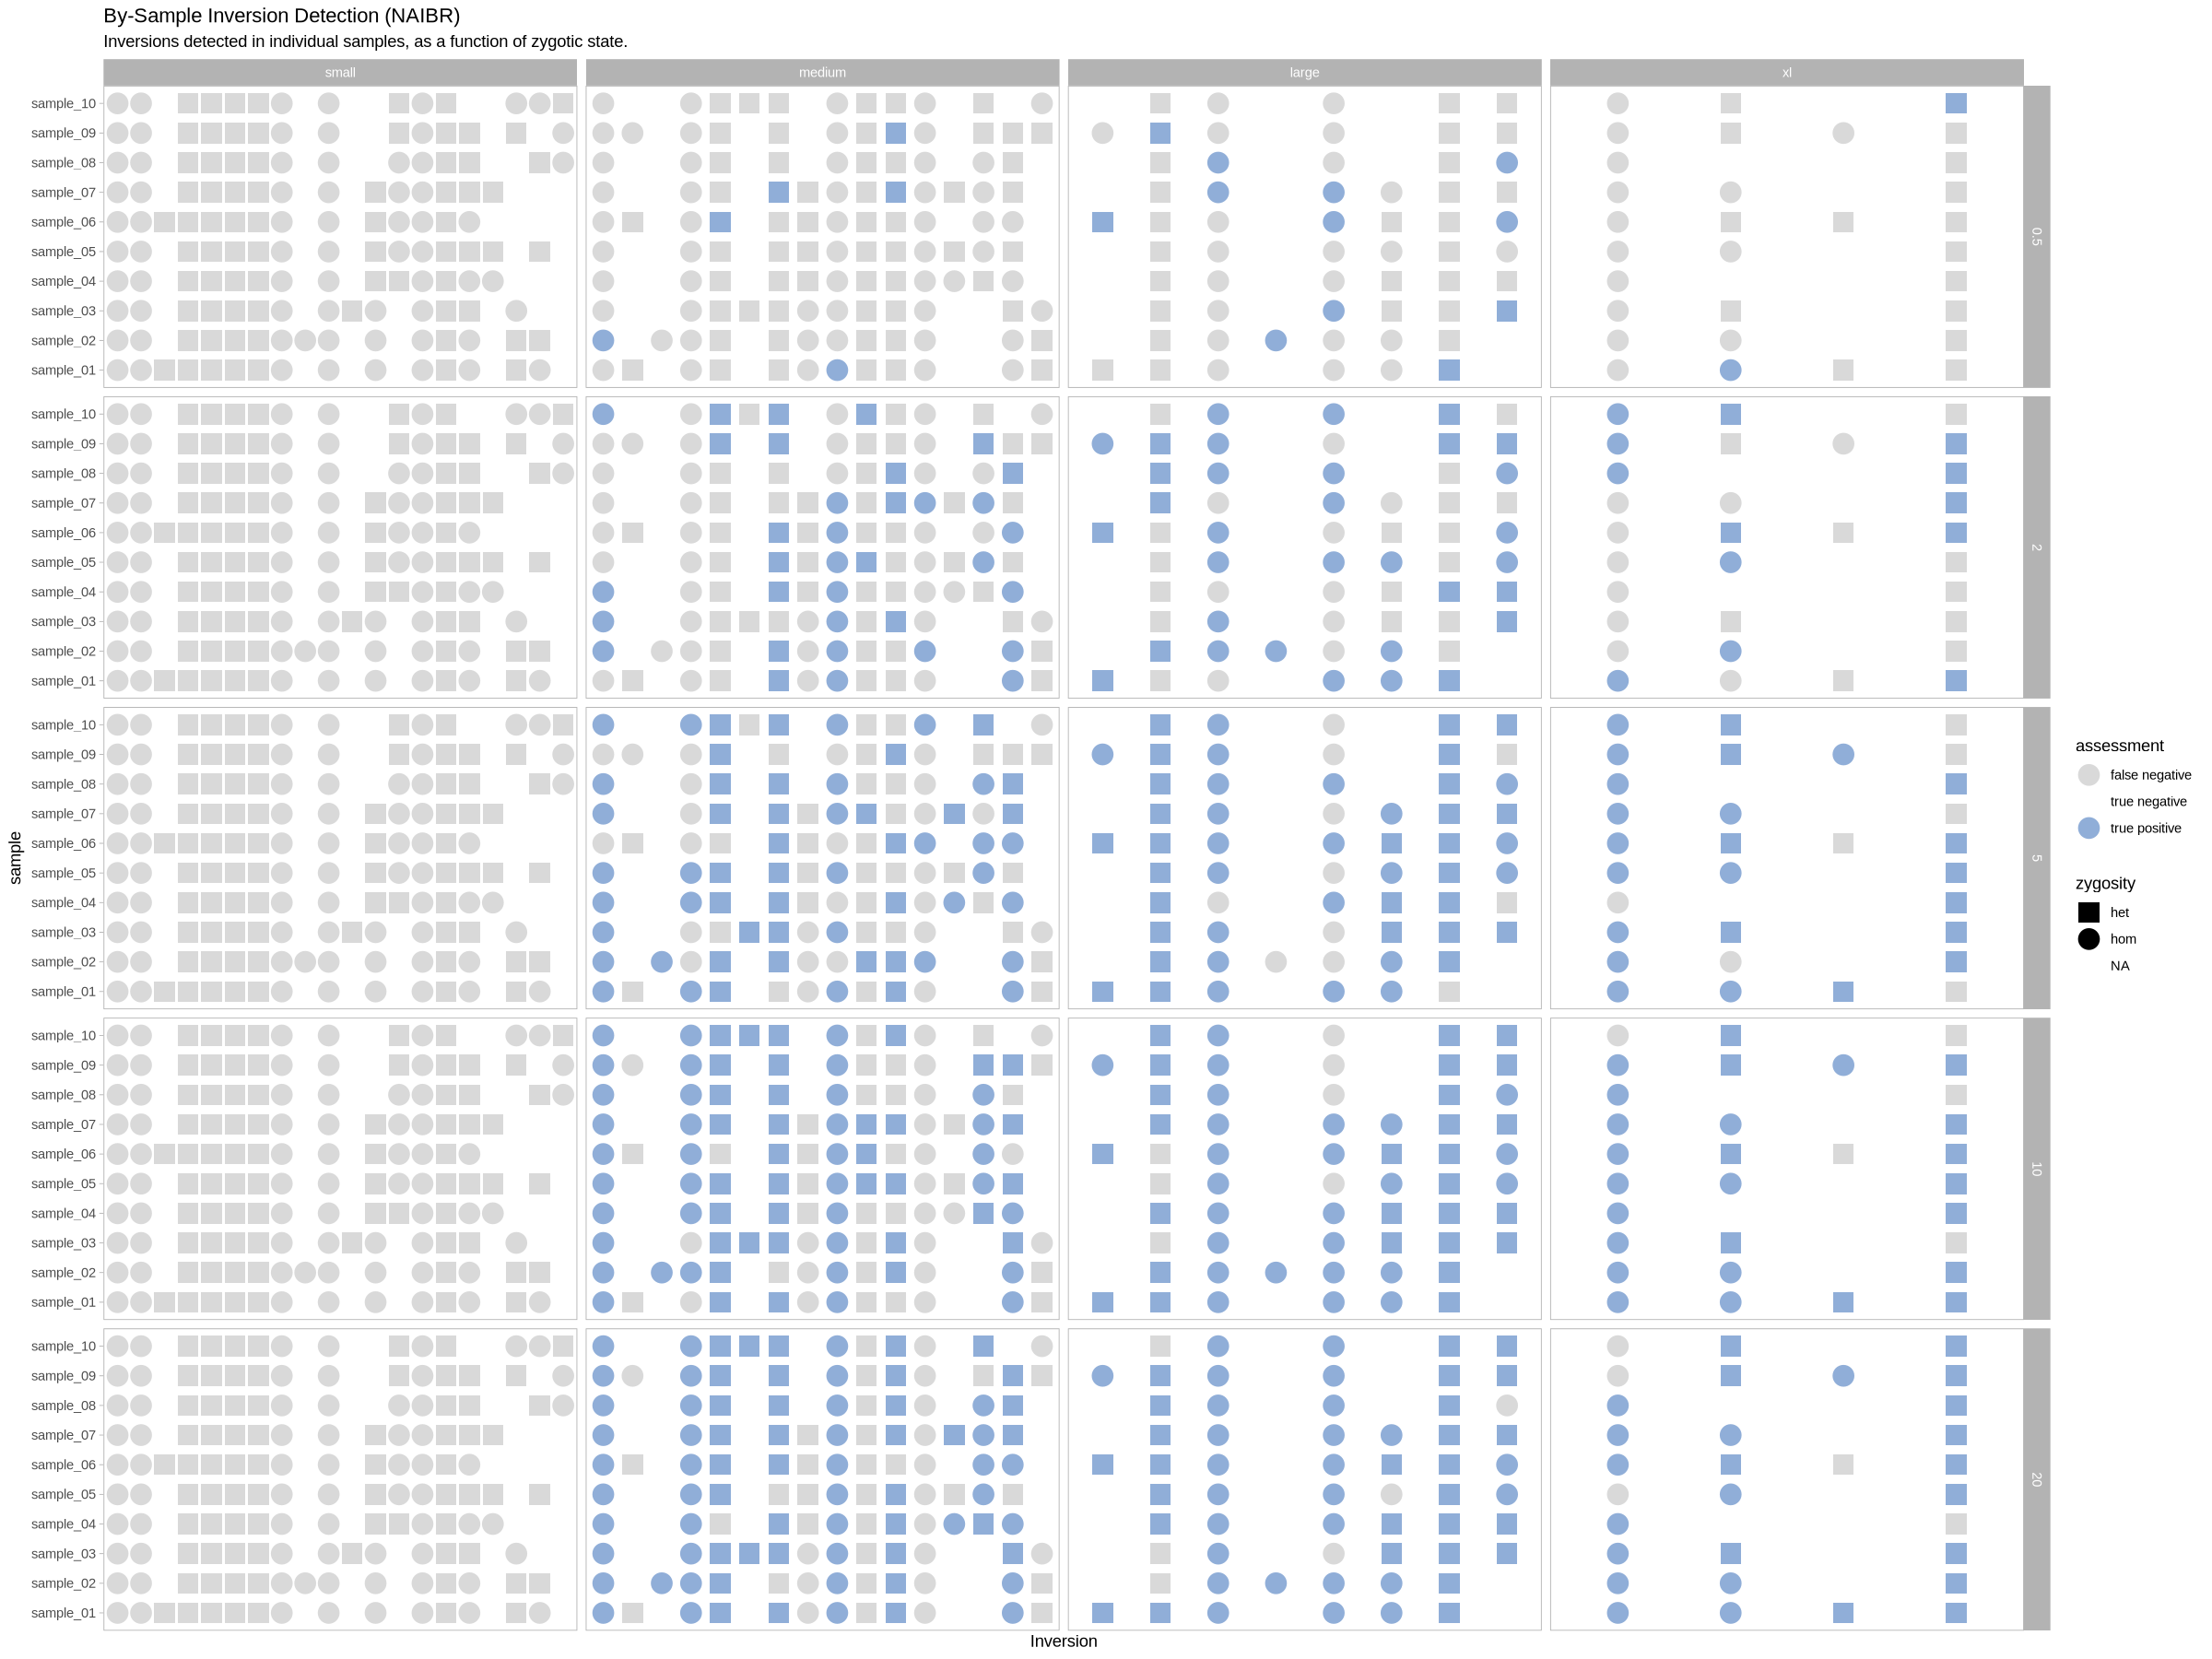

In [3]:
options(warn = -1, repr.plot.width = 20, repr.plot.height = 15)
axis_ticks <- factor(paste0("sample_", sprintf("%02d", 1:10)))
lr_inversions[lr_inversions$sample != 11,] %>%
    ggplot(aes(y = sample, x = id, color = assessment, shape = zygosity)) +
        geom_point(size=6) +
        theme_light() +
        labs(title = "By-Sample Inversion Detection (NAIBR)", subtitle = "Inversions detected in individual samples, as a function of zygotic state.") +
        scale_color_manual(values = c("false negative" = "grey85", "true negative" = "white", "true positive" = "#90aed8")) +
        scale_shape_manual(values = c("hom" = 19, "het" = 15)) +
        scale_x_discrete(name = "Inversion") +
        scale_y_discrete(limits = axis_ticks, breaks = axis_ticks) +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank()
        ) +
        facet_grid(depth ~ factor(size, levels = c("small", "medium", "large", "xl")), scales = "free_x")


### Pooled Sample Detection 

In [36]:
plot_pools_matrix <- function(data, size_treatment){
    .data <- data[data$sample == 11 & data$size == size_treatment,]
    .data$contig <- gsub("2L", "all hom", .data$contig)
    .data$contig <- gsub("2R", "all het", .data$contig)
    .data$contig <- gsub("3L", "inv common", .data$contig)
    .data$contig <- gsub("3R", "inv rare", .data$contig)
    .data$assessment <- factor(.data$assessment, levels = c("false negative", "true positive"))

    ggplot(.data, aes(y = 1, x = inversion, color = assessment)) +
        geom_point(size=8) +
        theme_light() +
        scale_color_manual(values = c("false negative" = "grey85", "true positive" = "#90aed8"), drop = F) +
        scale_y_continuous(breaks = 1, name = "") +
        scale_x_discrete(name = "Inversion") +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank(),
            axis.label.y = element_blank()
        ) +
        facet_grid(cols = vars(contig), rows = vars(depth))
}

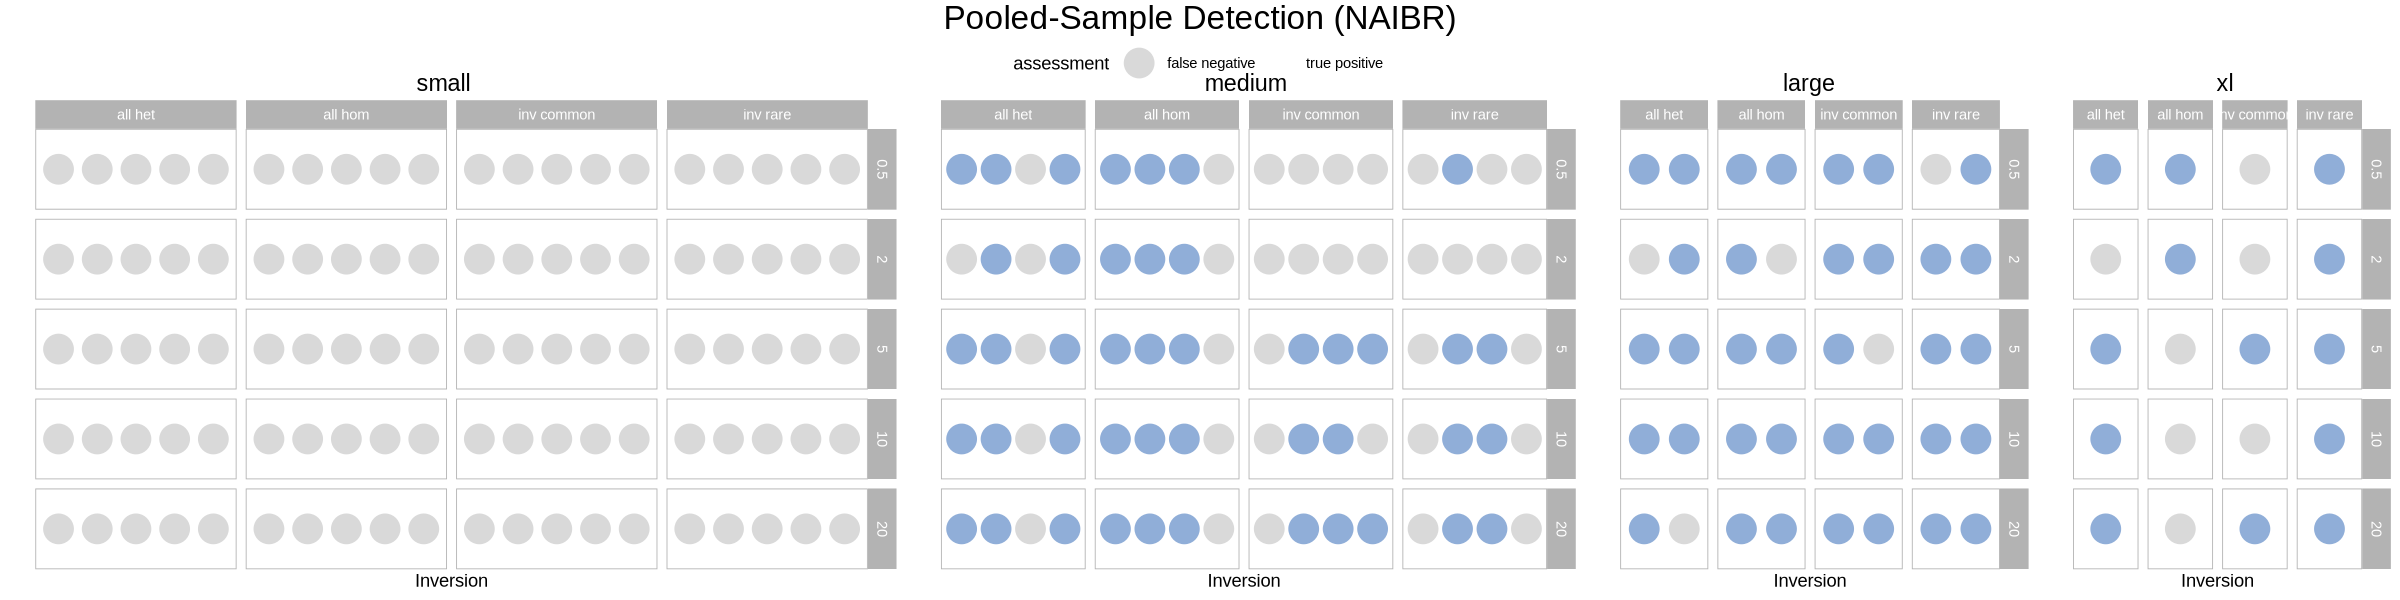

In [40]:
options(warn = -1, repr.plot.width = 20, repr.plot.height = 5)
plot <- ggarrange(
    plot_pools_matrix(lr_inversions, "small"),
    plot_pools_matrix(lr_inversions, "medium"),
    plot_pools_matrix(lr_inversions, "large"),
    plot_pools_matrix(lr_inversions, "xl"),
    labels = c("small", "medium", "large", "xl"),
    nrow = 1, ncol = 4, common.legend = T, font.label = c(face = "plain"), legend = "top",
    vjust = 0, label.x = c(0.43, 0.38, 0.38, 0.47),
    widths = c(1, .75, .50, .40)
)
annotate_figure(
    plot,
    top = text_grob(
        "Pooled-Sample Detection (NAIBR)", color = "black", size = 20
        )
)